# 1. EDA (Exploratory Data Analysis)

## 1.1. Import dataset

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/Customer-Churn-Records.csv')

In [ ]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,0,3,DIAMOND,911


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## 1.2. Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

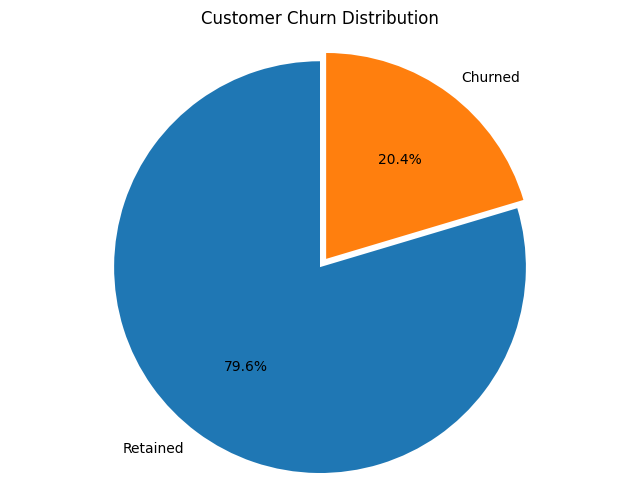

In [ ]:
churn_counts = df['Exited'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%', startangle=90, explode=[0.05,0])
plt.title('Customer Churn Distribution')
plt.axis('equal')
plt.show()

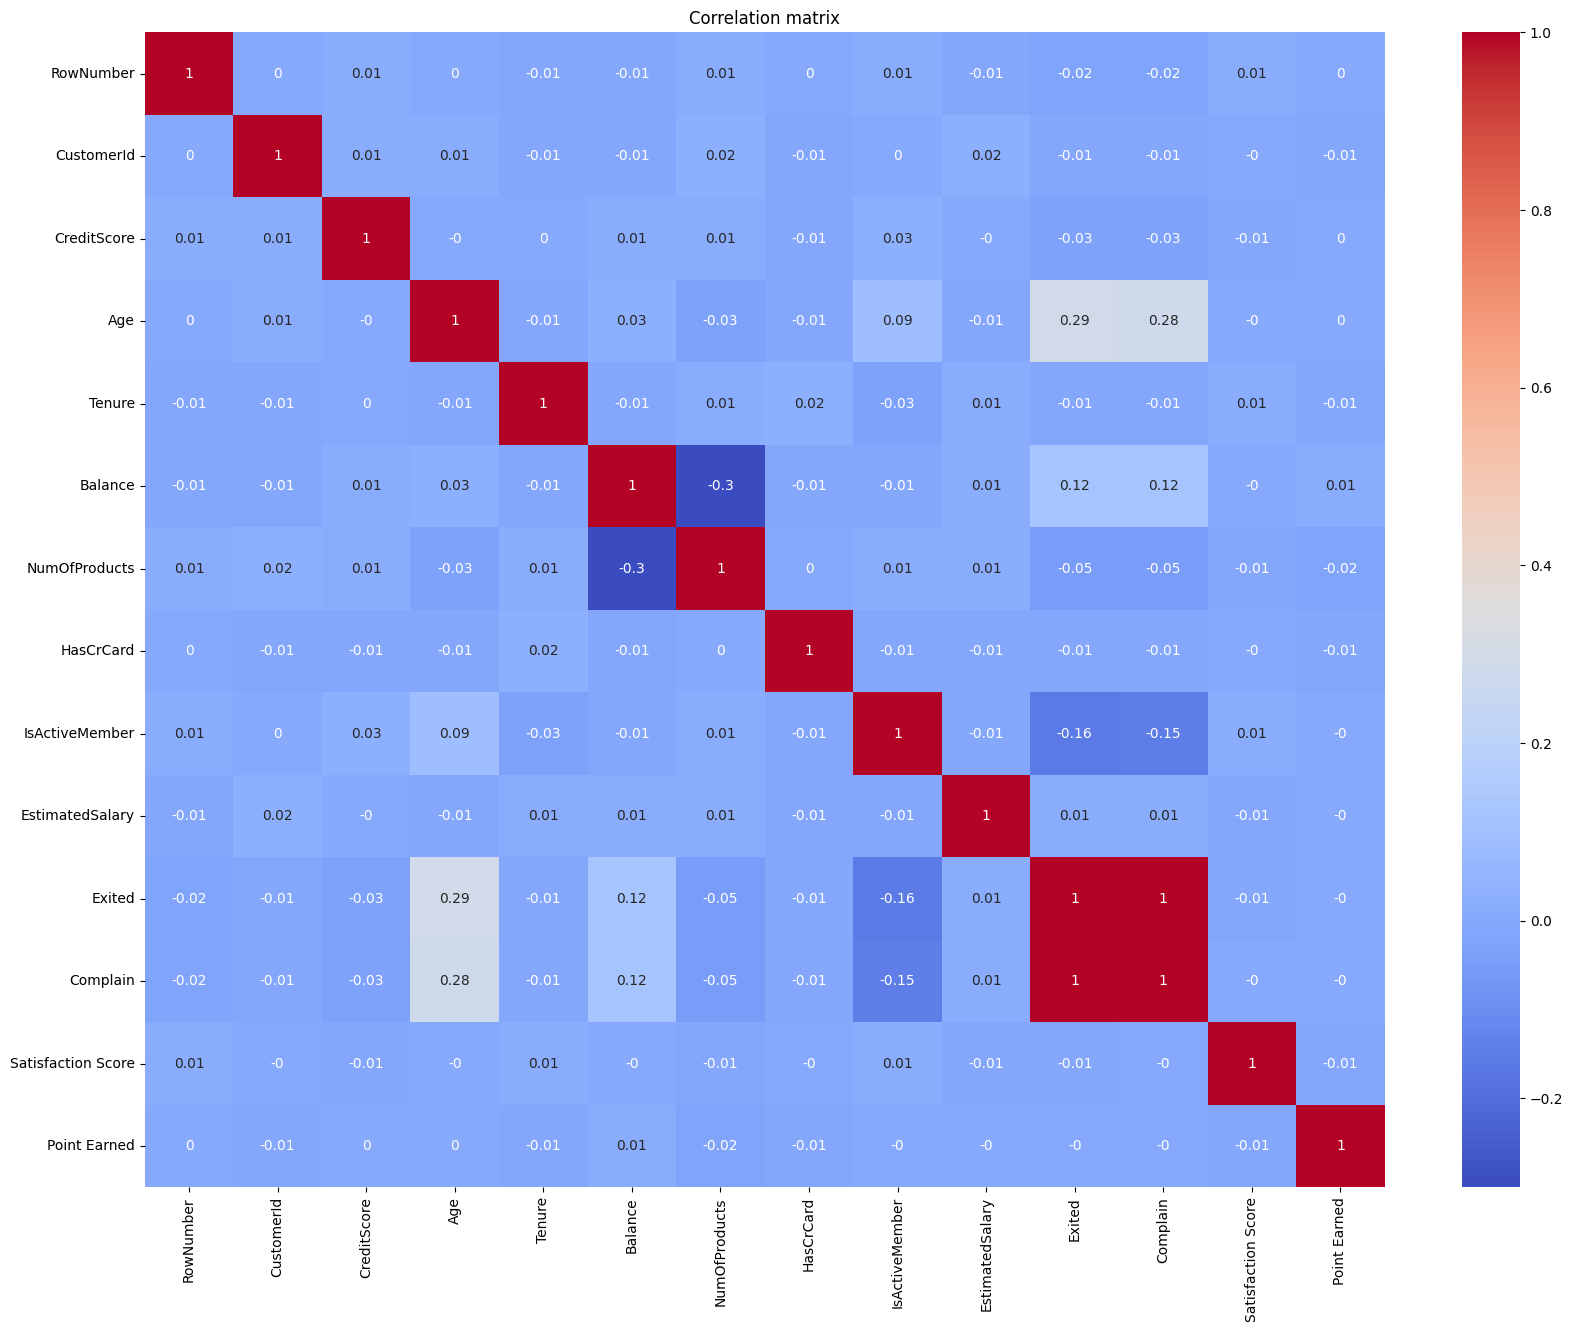

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(numeric_only=True).round(2), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

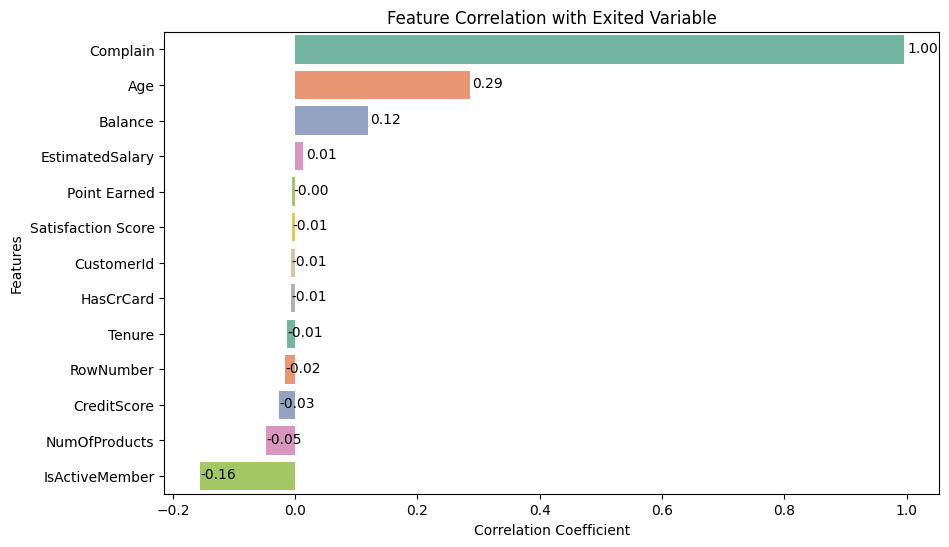

In [ ]:
df_corr = df.corr(numeric_only=True)['Exited'].drop('Exited').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=df_corr.values, y=df_corr.index, palette='Set2', hue=df_corr.index, legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width() + 0.03, p.get_y() + p.get_height() / 2),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 1), textcoords='offset points')

plt.title('Feature Correlation with Exited Variable')
plt.ylabel('Features')
plt.xlabel('Correlation Coefficient')
plt.show()

In [ ]:
df = df.drop('Complain', axis = 1)

<Axes: title={'center': 'Variable Satisfaction Score'}, xlabel='Card Type', ylabel='count'>

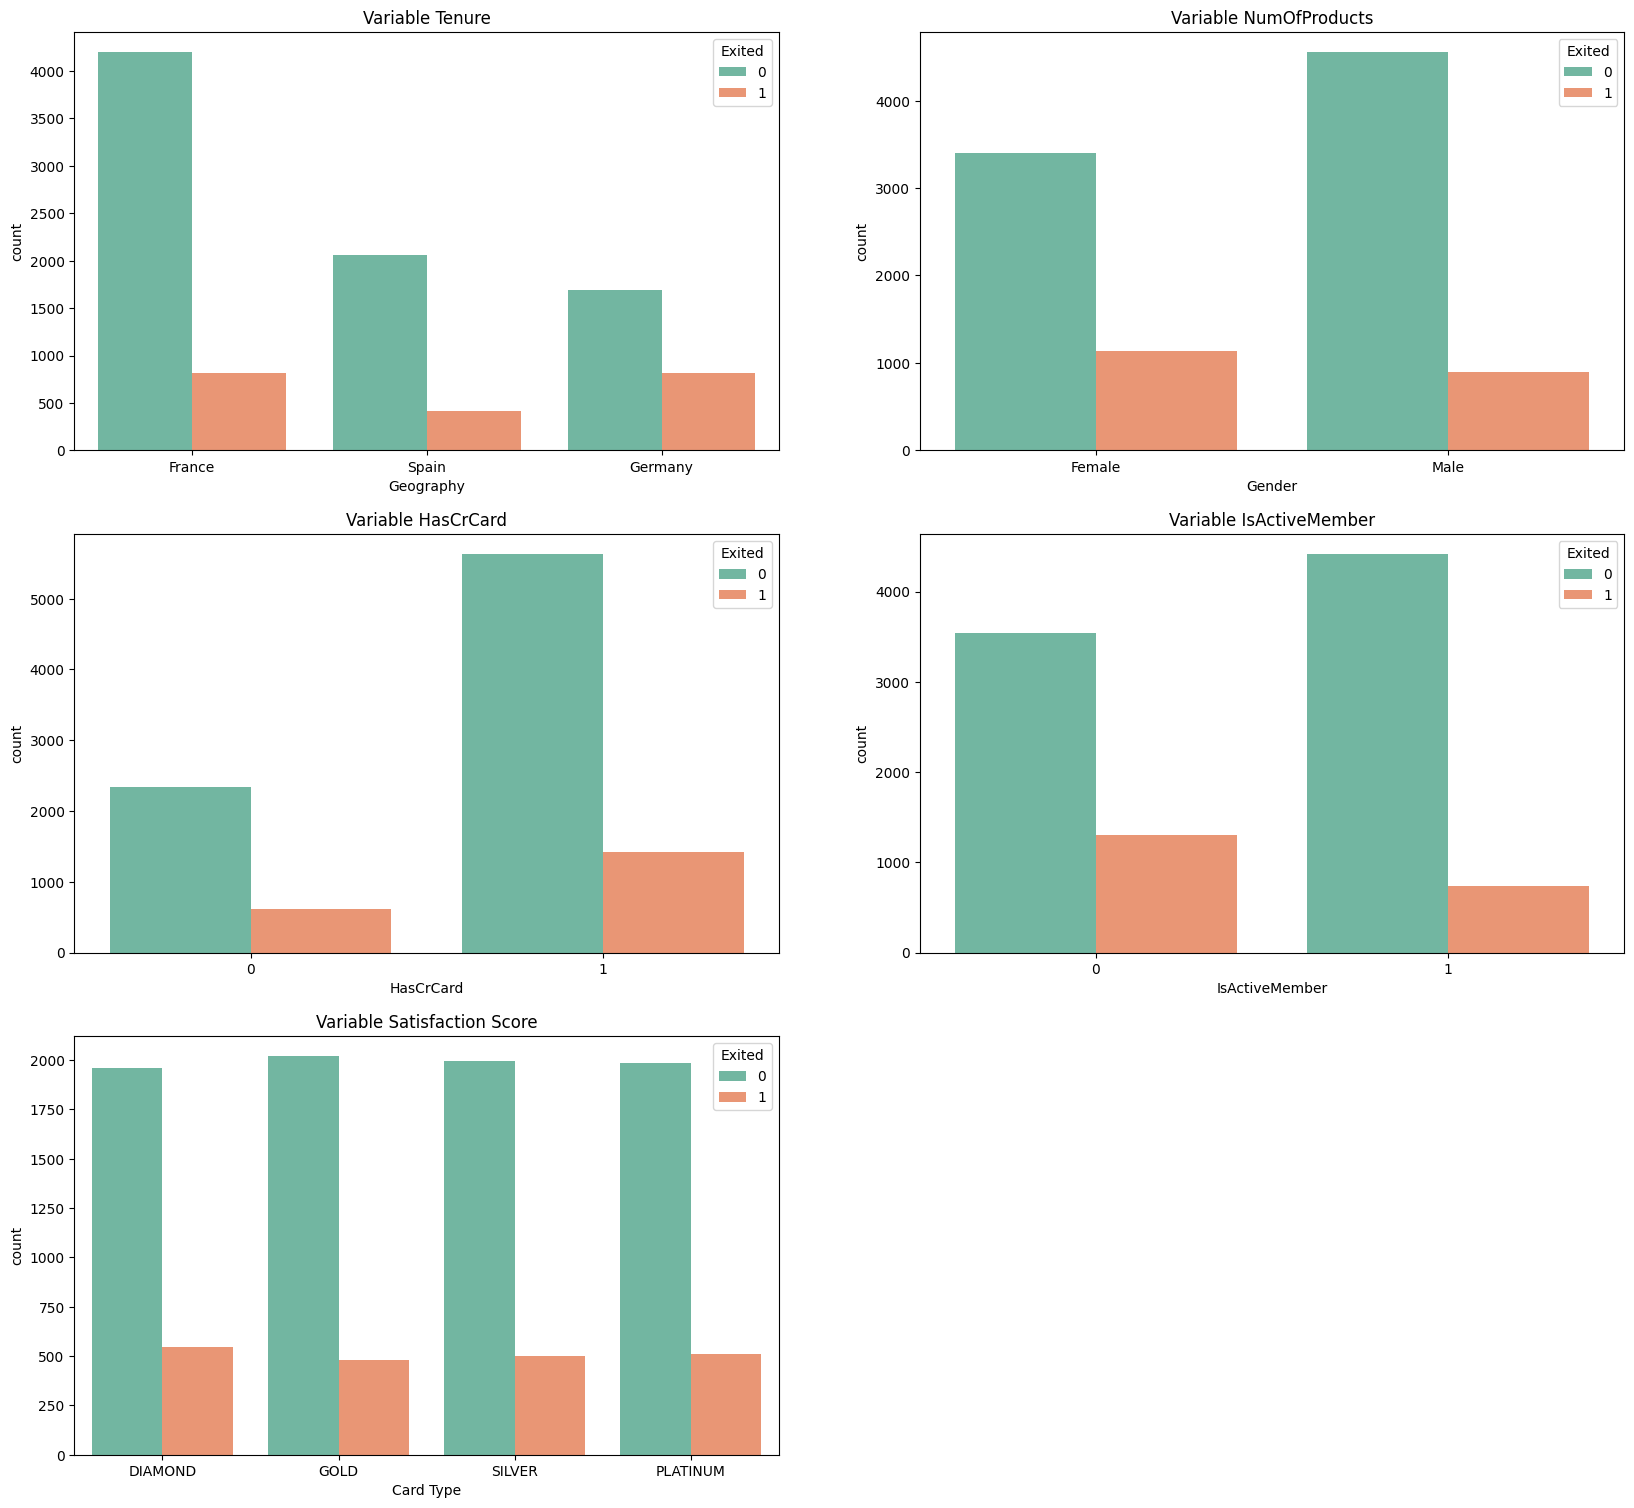

In [ ]:
plt.figure(figsize = (20, 25))

plt.subplot(4, 2, 1)
plt.gca().set_title('Variable Tenure')
sns.countplot(x = 'Geography', hue = 'Exited', data = df, palette='Set2')

plt.subplot(4, 2, 2)
plt.gca().set_title('Variable NumOfProducts')
sns.countplot(x = 'Gender', hue = 'Exited', data = df, palette='Set2')

plt.subplot(4, 2, 3)
plt.gca().set_title('Variable HasCrCard')
sns.countplot(x = 'HasCrCard', hue = 'Exited', data = df, palette='Set2')

plt.subplot(4, 2, 4)
plt.gca().set_title('Variable IsActiveMember')
sns.countplot(x = 'IsActiveMember', hue = 'Exited', data = df, palette='Set2')

plt.subplot(4, 2, 5)
plt.gca().set_title('Variable Satisfaction Score')
sns.countplot(x = 'Card Type', hue = 'Exited', data = df, palette='Set2')

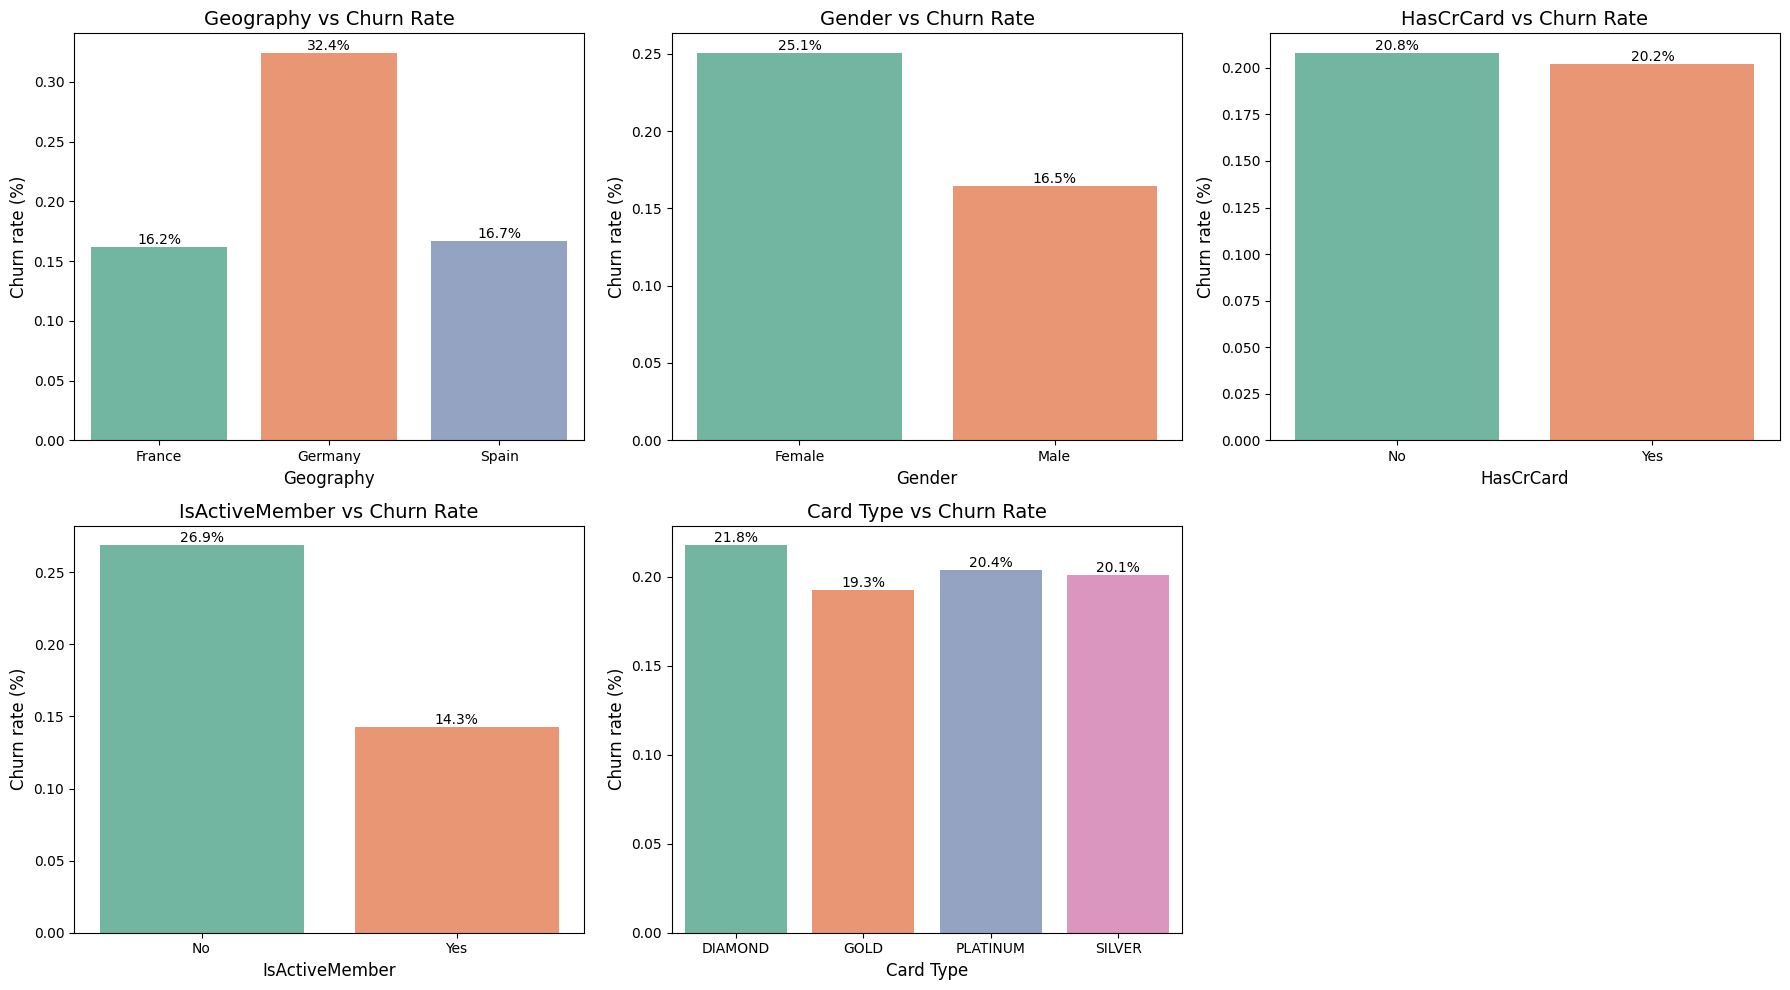

In [ ]:
# Tạo bản sao và đổi nhãn cho các cột nhị phân
df_plot = df.assign(
    HasCrCard=df['HasCrCard'].map({0: 'No', 1: 'Yes'}),
    IsActiveMember=df['IsActiveMember'].map({0: 'No', 1: 'Yes'})
)

# Danh sách đặc trưng cần vẽ
features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Card Type']

# Tạo subplot phù hợp với số lượng đặc trưng
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Vẽ từng biểu đồ con: tỷ lệ churn theo từng giá trị
for i, feature in enumerate(features):
    # Tính tỷ lệ churn cho từng nhóm
    churn_rate = df_plot.groupby(feature)['Exited'].mean().reset_index()

    sns.barplot(data=churn_rate, x=feature, y='Exited', hue=feature, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'{feature} vs Churn Rate', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Churn rate (%)', fontsize=12)

    # Hiển thị giá trị phần trăm trên cột
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height()*100:.1f}%',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontsize=10, color='black')

# Ẩn subplot dư
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Variable Satisfaction Score'}, xlabel='Satisfaction Score', ylabel='count'>

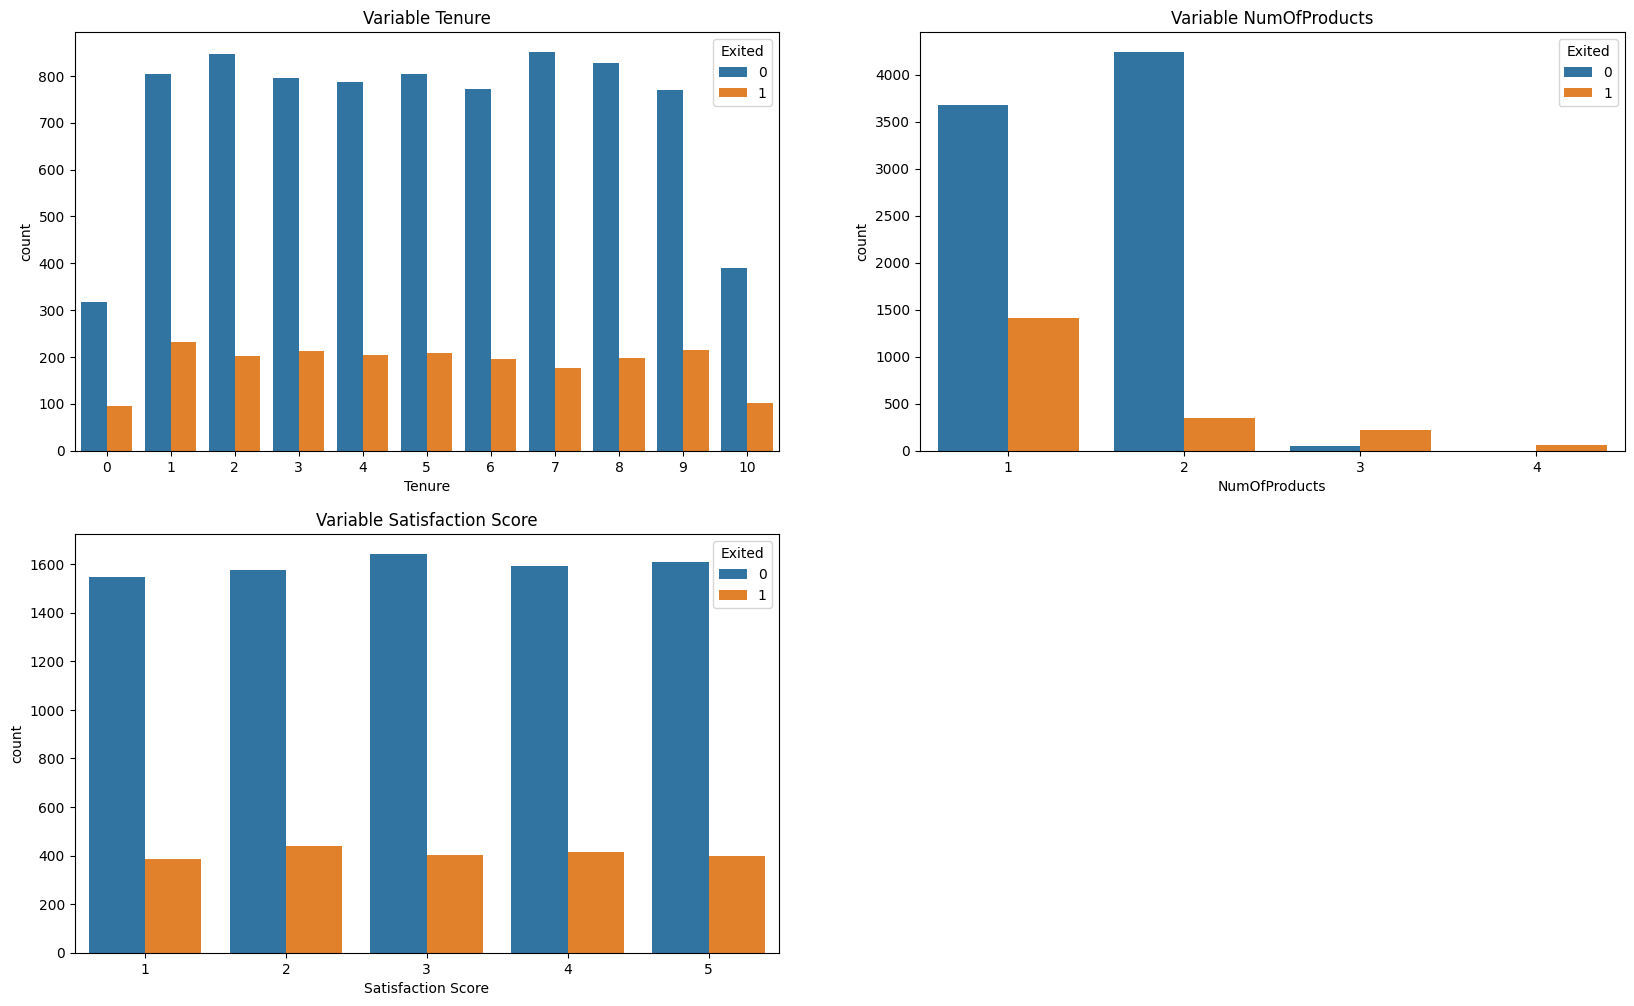

In [ ]:
plt.figure(figsize = (20, 25))

plt.subplot(4, 2, 1)
plt.gca().set_title('Variable Tenure')
sns.countplot(x = 'Tenure', hue = 'Exited', data = df)

plt.subplot(4, 2, 2)
plt.gca().set_title('Variable NumOfProducts')
sns.countplot(x = 'NumOfProducts', hue = 'Exited', data = df)

plt.subplot(4, 2, 3)
plt.gca().set_title('Variable Satisfaction Score')
sns.countplot(x = 'Satisfaction Score', hue = 'Exited', data = df)

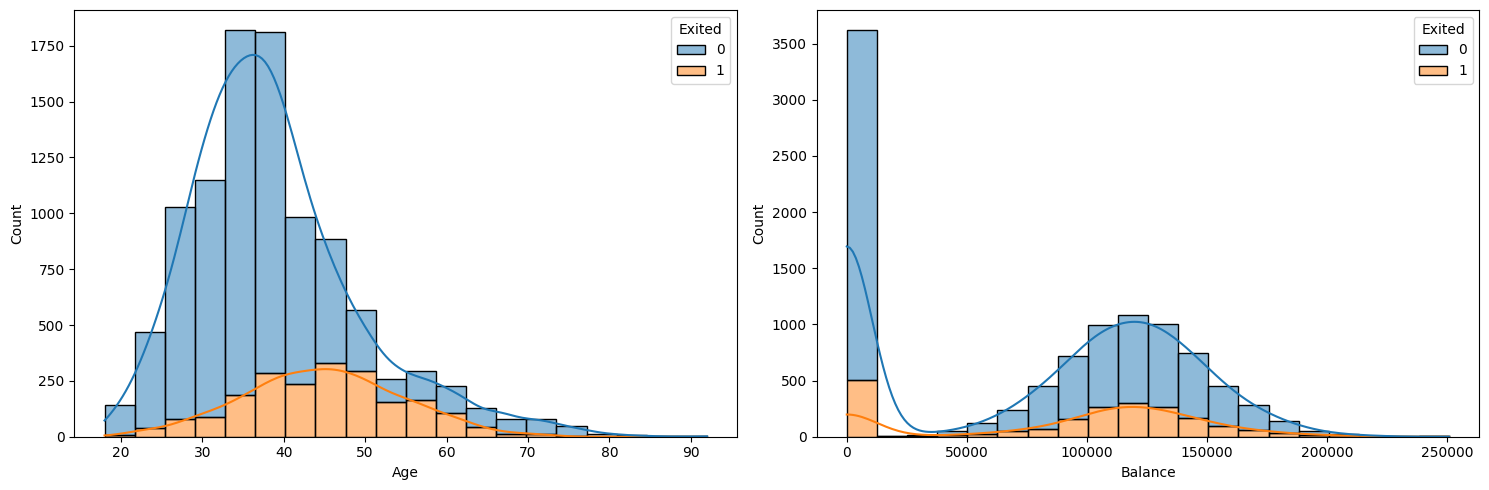

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.histplot(df, x='Age', hue='Exited', multiple='stack', bins=20, kde=True, ax=ax[0])
sns.histplot(df, x='Balance', hue='Exited', multiple='stack', bins=20, kde=True, ax=ax[1])
plt.tight_layout()
plt.show()

<Axes: xlabel='Exited', ylabel='CreditScore'>

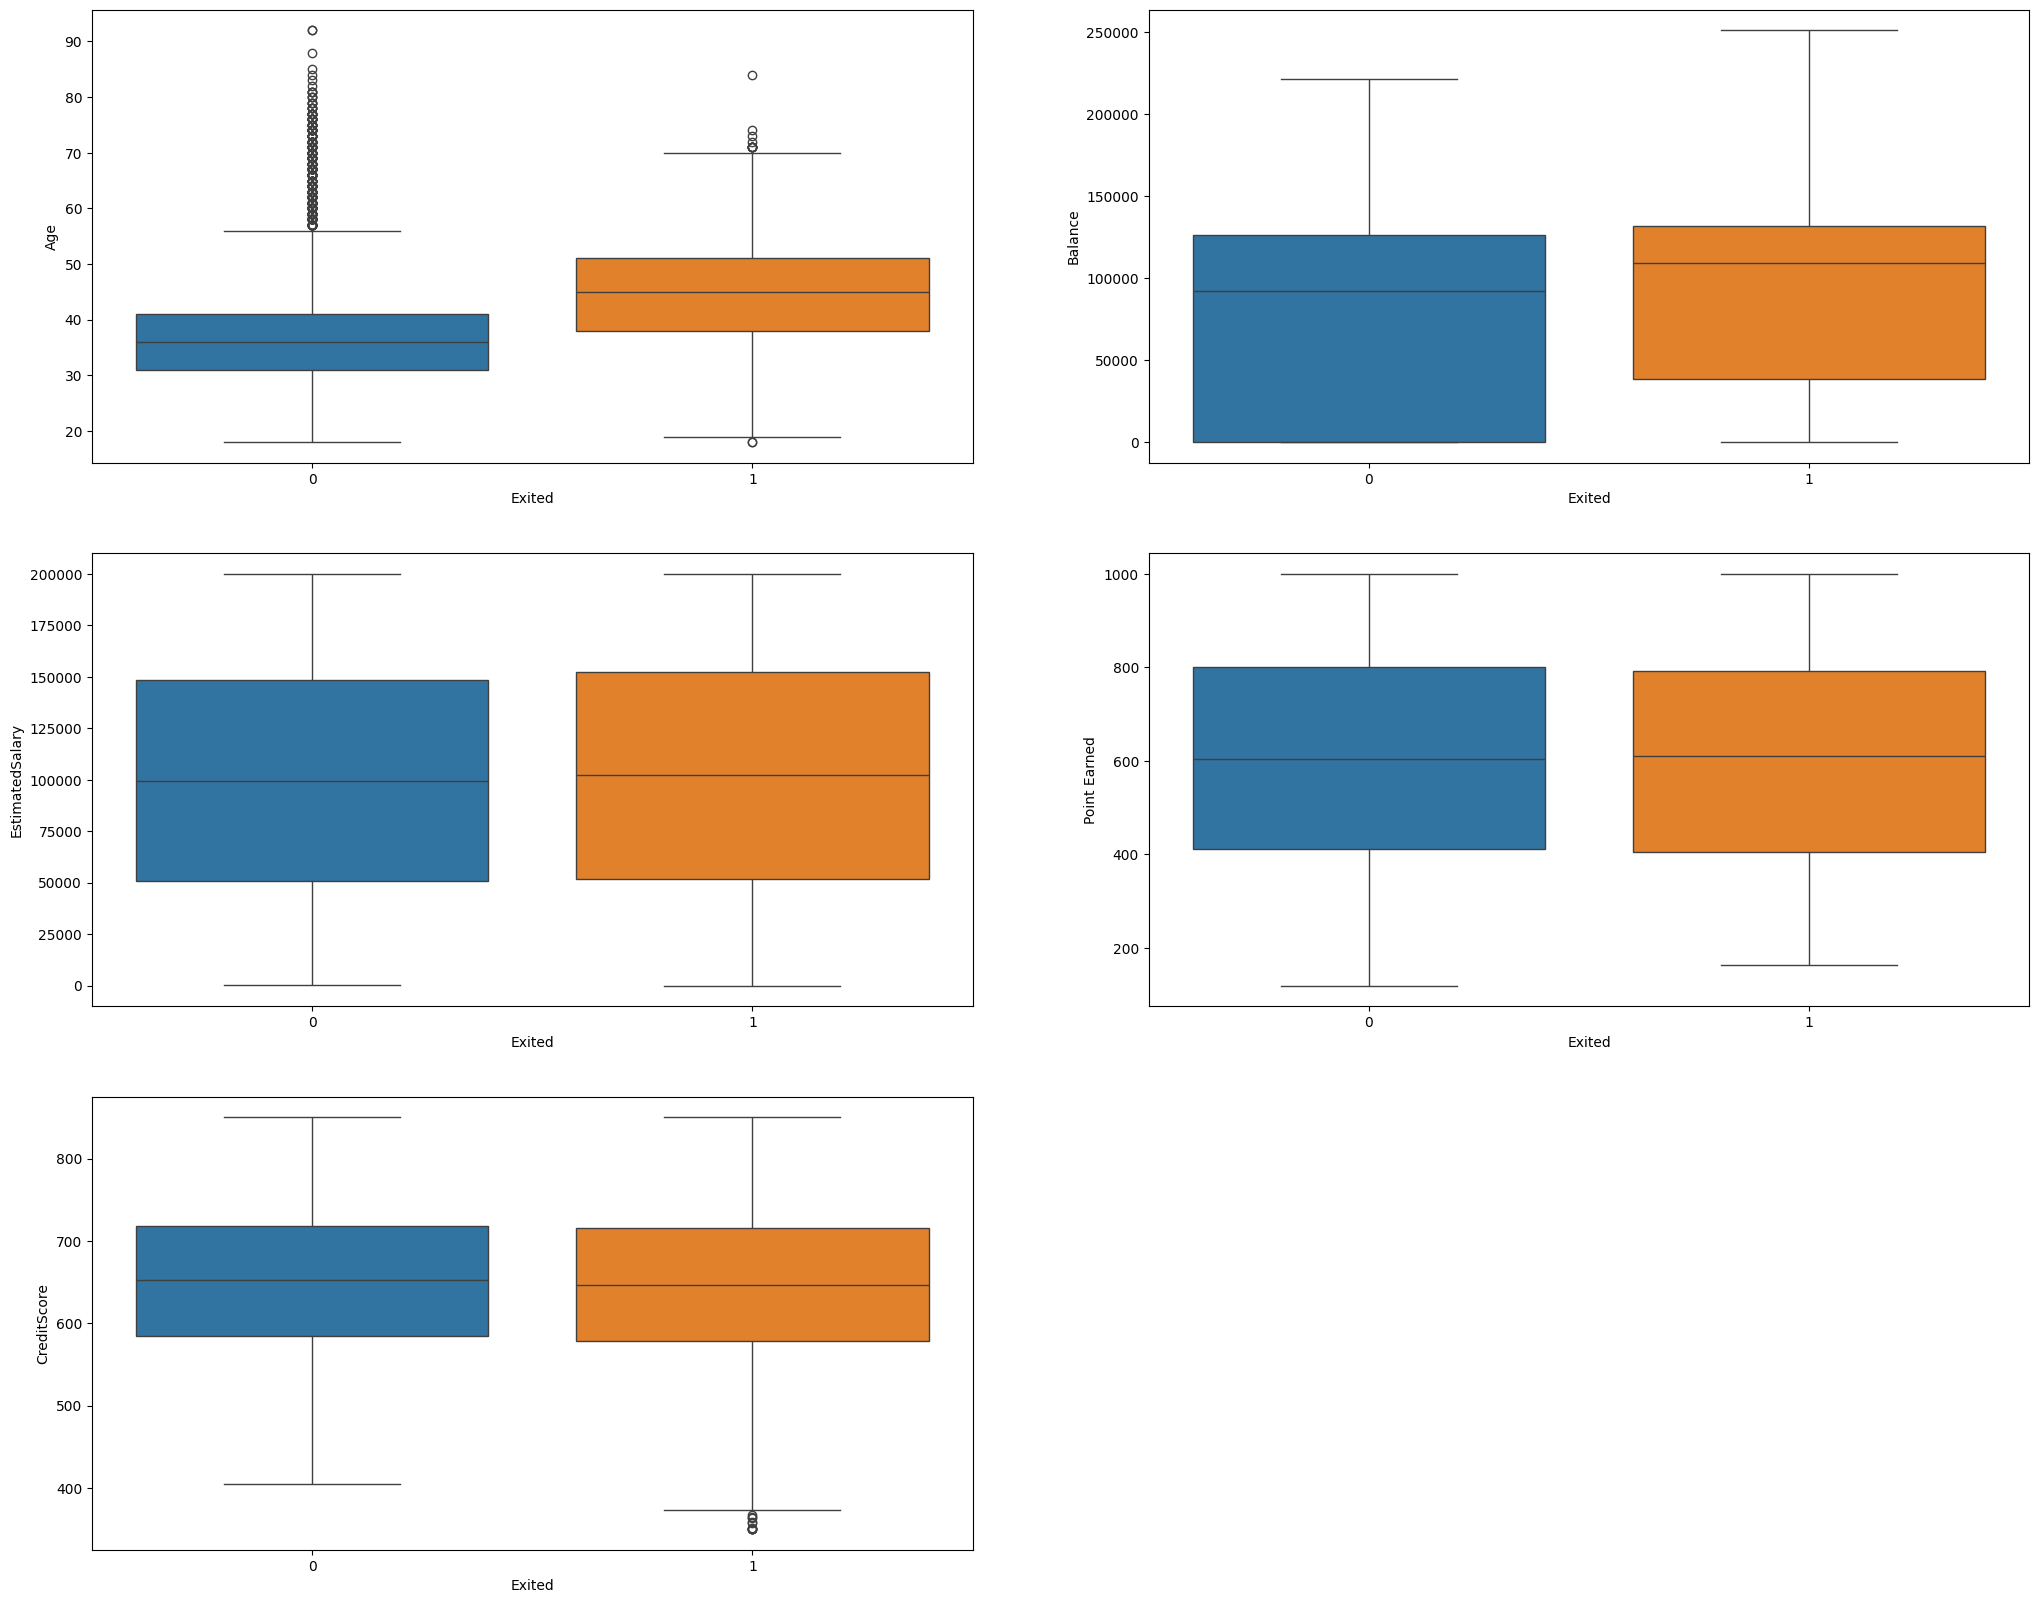

In [ ]:
plt.figure(figsize = (25, 20))

plt.subplot(3,2,1)
sns.boxplot(x="Exited", y="Age", data=df, hue='Exited', legend=False)

plt.subplot(3,2,2)
sns.boxplot(x="Exited", y="Balance", data=df, hue='Exited', legend=False)

plt.subplot(3,2,3)
sns.boxplot(x="Exited", y="EstimatedSalary", data=df, hue='Exited', legend=False)

plt.subplot(3,2,4)
sns.boxplot(x="Exited", y="Point Earned", data=df, hue='Exited', legend=False)

plt.subplot(3,2,5)
sns.boxplot(x="Exited", y="CreditScore", data=df, hue='Exited', legend=False)

# 2. Data Preprocessing


## 2.1. Drop columns

In [ ]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2,GOLD,339


## 2.2. Data seperating

In [ ]:
allowed_geo = ['France', 'Germany', 'Spain']

def clean_geo(geo):
  if geo not in allowed_geo:
    return 'Other'
  return geo

df['Geography'] = df['Geography'].apply(clean_geo)

In [ ]:
X = df.drop('Exited', axis = 1)
y = df['Exited']

In [ ]:
numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary','Point Earned','Satisfaction Score']
categorical_cols = ['Geography','Gender','Card Type','HasCrCard','IsActiveMember']

## 2.3. ColumnTransformer

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
num_pipe = Pipeline([('scaler', StandardScaler())])
cat_pipe = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

num_tree = 'passthrough'
cat_tree = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [ ]:
preprocess = ColumnTransformer([
    ("cat", cat_pipe, categorical_cols),
    ("num", num_pipe, numeric_cols)
], remainder='drop')

preprocess_tree = ColumnTransformer([
    ("cat", cat_tree, categorical_cols),
    ("num", num_tree, numeric_cols)
], remainder='drop')

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Train shape", X_train.shape)
print("Test shape", X_test.shape)

Train shape (7000, 13)
Test shape (3000, 13)


In [ ]:
preprocess.fit(X_train)
scaler = preprocess.named_transformers_['num'].named_steps['scaler']

scaled_num = scaler.transform(X_train[numeric_cols])
df_scaler = pd.DataFrame(scaled_num, columns=numeric_cols)

df_scaler.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Point Earned,Satisfaction Score
count,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03
mean,5.283393e-16,-3.298948e-17,1.796658e-16,8.628019e-17,1.421085e-16,9.440068e-17,9.947598e-17,7.206933e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-3.111542e+00,-1.982824e+00,-1.733250e+00,-1.230034e+00,-9.104140e-01,-1.731202e+00,-2.168036e+00,-1.425299e+00
25%,-6.908411e-01,-6.574971e-01,-6.941313e-01,-1.230034e+00,-9.104140e-01,-8.603814e-01,-8.715448e-01,-7.171010e-01
50%,1.261040e-02,-1.841663e-01,-1.385492e-03,3.266976e-01,-9.104140e-01,-1.171874e-02,-5.737165e-03,-8.903059e-03
75%,6.953722e-01,4.784969e-01,6.913603e-01,8.223178e-01,8.041133e-01,8.541326e-01,8.556305e-01,6.992948e-01
max,2.060896e+00,5.022473e+00,1.730479e+00,2.336495e+00,4.233168e+00,1.749065e+00,1.743638e+00,1.407493e+00


In [ ]:
df_scaler.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Point Earned,Satisfaction Score
0,1.626411,-1.320160,0.691360,-1.230034,0.804113,-1.327996,-0.978106,0.699295
1,-0.928773,1.614491,0.691360,1.221152,0.804113,0.586103,-1.022506,-0.717101
2,0.467785,-0.562831,-0.347758,-1.230034,0.804113,-0.454517,-1.151267,-0.008903
3,-0.142563,-1.604159,-0.001385,0.355321,-0.910414,0.406825,-0.787184,-0.717101
4,0.405716,0.005166,0.344987,-1.230034,0.804113,1.062350,-0.400901,-1.425299


In [ ]:
ohe = preprocess.named_transformers_['cat'].named_steps['onehot']
ohe_cat = ohe.transform(X_train[categorical_cols])

pd.DataFrame(ohe_cat, columns=ohe.get_feature_names_out(categorical_cols)).head()

,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,HasCrCard_0,HasCrCard_1,IsActiveMember_0,IsActiveMember_1
0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0


# 4. Model Building

## 4.1. Logistic Regression

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()

logistic_pipeline = ImbPipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('logistic', logistic_model)
])

logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)
y_proba_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

auc_logistic = roc_auc_score(y_test, y_proba_logistic)
acc_logistic = accuracy_score(y_test, y_pred_logistic)
prec_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)
rec_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)
f1_logistic = f1_score(y_test, y_pred_logistic, zero_division=0)

print(f'Acc: {acc_logistic:.4f}, Prec: {prec_logistic:.4f}, Rec: {rec_logistic:.4f}, F1: {f1_logistic:.4f}, AUC: {auc_logistic:.4f}')
print((classification_report(y_test, y_pred_logistic)))

Acc: 0.7153, Prec: 0.3916, Rec: 0.7185, F1: 0.5069, AUC: 0.7858
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      2389
           1       0.39      0.72      0.51       611

    accuracy                           0.72      3000
   macro avg       0.65      0.72      0.65      3000
weighted avg       0.80      0.72      0.74      3000



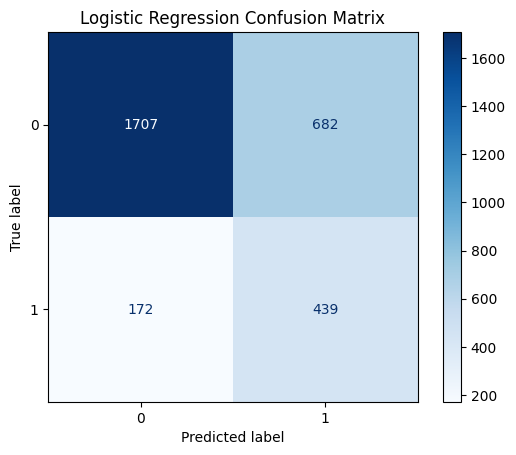

In [ ]:
cm = confusion_matrix(y_test, y_pred_logistic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.gca().grid(False)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

## 4.2. SVM (Support Vector Machines)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42, C=1.0, probability=True, gamma='scale')

svm_pipeline = ImbPipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('svm', svm_model)
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

auc_svm = roc_auc_score(y_test, y_proba_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

print(f'Acc: {acc_svm:.4f}, Prec: {prec_svm:.4f}, Rec: {rec_svm:.4f}, F1: {f1_svm:.4f}, AUC: {auc_svm:.4f}')
print((classification_report(y_test, y_pred_svm)))

Acc: 0.8033, Prec: 0.5129, Rec: 0.6841, F1: 0.5863, AUC: 0.8464
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      2389
           1       0.51      0.68      0.59       611

    accuracy                           0.80      3000
   macro avg       0.71      0.76      0.73      3000
weighted avg       0.83      0.80      0.81      3000



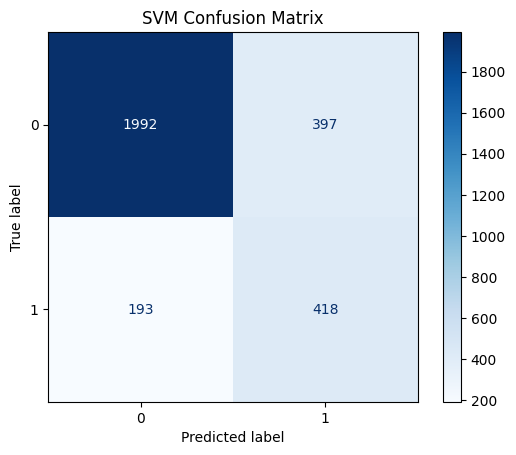

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.gca().grid(False)
plt.title('SVM Confusion Matrix')
plt.show()


## 4.3. KNN (K-Nearest Neighbors)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 21)
results = []

for k in k_values:
    knn_model = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='manhattan',
        n_jobs=-1
    )

    knn_pipeline = ImbPipeline([
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=42)),
        ('knn', knn_model)
    ])

    knn_pipeline.fit(X_train, y_train)

    y_pred_knn = knn_pipeline.predict(X_test)
    y_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]

    results.append({
        'k': k,
        'recall': recall_score(y_test, y_pred_knn),
        'f1_score': f1_score(y_test, y_pred_knn),
        'roc_auc': roc_auc_score(y_test, y_proba_knn)
    })

df_results = pd.DataFrame(results)
df_results

,k,recall,f1_score,roc_auc
0,1,0.420622,0.429048,0.641244
1,2,0.420622,0.429048,0.686996
2,3,0.505728,0.462575,0.722011
3,4,0.504092,0.466667,0.739037
4,5,0.566285,0.494993,0.750366
5,6,0.551555,0.494860,0.758919
6,7,0.585925,0.507801,0.767928
7,8,0.581015,0.513377,0.775489
8,9,0.612111,0.523810,0.780742
9,10,0.579378,0.507527,0.785347


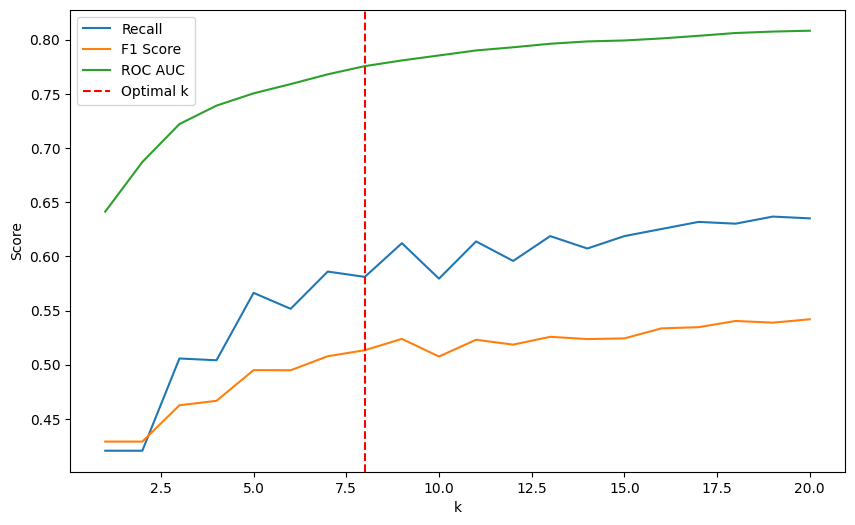

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_results['k'], df_results['recall'], label='Recall')
plt.plot(df_results['k'], df_results['f1_score'], label='F1 Score')
plt.plot(df_results['k'], df_results['roc_auc'], label='ROC AUC')
plt.xlabel('k')
plt.ylabel('Score')
plt.axvline(x=8, color='red', linestyle='--', label='Optimal k')
plt.legend()
plt.show()

We will use k = 8

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=8)

knn_pipeline = ImbPipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('knn', knn_model)
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
y_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]

auc_knn = roc_auc_score(y_test, y_proba_knn)
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)
rec_knn = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, zero_division=0)

print(f'Acc: {acc_knn:.4f}, Prec: {prec_knn:.4f}, Rec: {rec_knn:.4f}, F1: {f1_knn:.4f}, AUC: {auc_knn:.4f}')
print((classification_report(y_test, y_pred_knn)))

Acc: 0.7550, Prec: 0.4347, Rec: 0.6759, F1: 0.5291, AUC: 0.7932
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      2389
           1       0.43      0.68      0.53       611

    accuracy                           0.76      3000
   macro avg       0.67      0.73      0.68      3000
weighted avg       0.81      0.76      0.77      3000



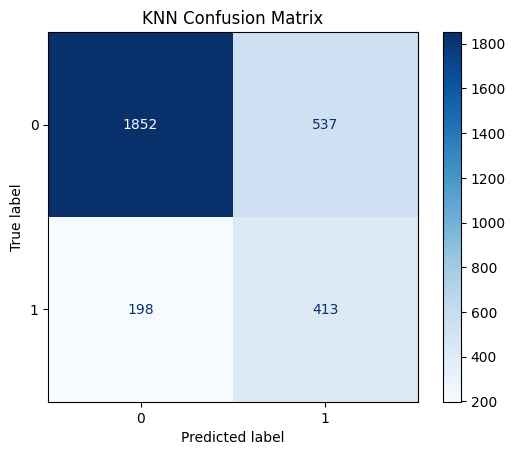

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.gca().grid(False)
plt.title('KNN Confusion Matrix')
plt.show()

## 4.4. Random Forest

All tree-based models can handle raw data well

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split = 7, max_depth = 11,  criterion = 'entropy')

rf_pipeline = ImbPipeline([
    ('preprocess', preprocess_tree),
    ('smote', SMOTE(random_state=42)),
    ('rf', rf_model)
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print(f'Acc: {acc_rf:.4f}, Prec: {prec_rf:.4f}, Rec: {rec_rf:.4f}, F1: {f1_rf:.4f}, AUC: {auc_rf:.4f}')
print((classification_report(y_test, y_pred_rf)))

Acc: 0.8687, Prec: 0.7577, Rec: 0.5221, F1: 0.6182, AUC: 0.8674
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      2389
           1       0.76      0.52      0.62       611

    accuracy                           0.87      3000
   macro avg       0.82      0.74      0.77      3000
weighted avg       0.86      0.87      0.86      3000



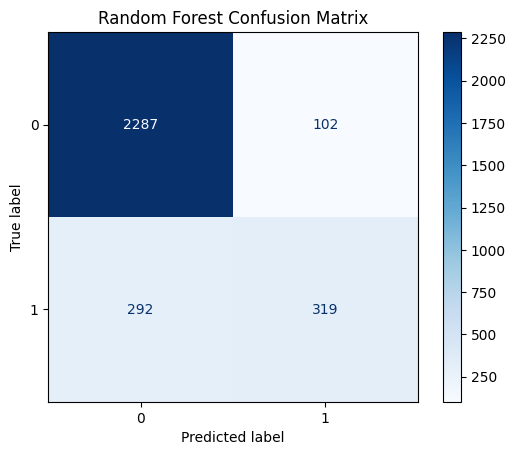

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.gca().grid(False)
plt.title('Random Forest Confusion Matrix')
plt.show()

## 4.5. XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
  random_state=42,
  scale_pos_weight=2.2,
  eval_metric='logloss'
)

xgb_pipeline = ImbPipeline([
    ('preprocess', preprocess_tree),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)

print(f'Acc: {acc_xgb:.4f}, Prec: {prec_xgb:.4f}, Rec: {rec_xgb:.4f}, F1: {f1_xgb:.4f}, AUC: {auc_xgb:.4f}')
print((classification_report(y_test, y_pred_xgb)))

Acc: 0.8470, Prec: 0.6301, Rec: 0.6023, F1: 0.6159, AUC: 0.8597
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      2389
           1       0.63      0.60      0.62       611

    accuracy                           0.85      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.84      0.85      0.85      3000



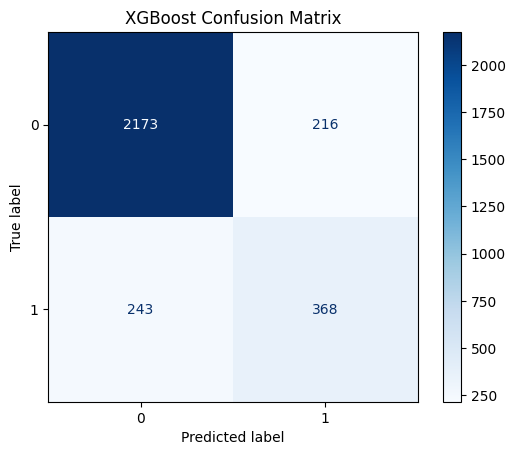

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.gca().grid(False)
plt.title('XGBoost Confusion Matrix')
plt.show()

### 4.5.1. Tune max_depth and min_child_weight

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'xgb__max_depth': range(3,10,2),
    'xgb__min_child_weight': range(1,6,2)
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best AUC: {grid_search.best_score_}")

Best parameters: {'xgb__max_depth': 3, 'xgb__min_child_weight': 3}
Best AUC: 0.8502794167468413


In [ ]:
param_grid_2 = {
    'xgb__max_depth': [2,3,4],
    'xgb__min_child_weight': [0,1,2]
}

grid_search_2 = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_2,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

grid_search_2.fit(X_train, y_train)

print(f"Best parameters: {grid_search_2.best_params_}")
print(f"Best AUC: {grid_search_2.best_score_}")

Best parameters: {'xgb__max_depth': 2, 'xgb__min_child_weight': 1}
Best AUC: 0.8512631554096608


We will use max_depth = 2, min_child_weight = 1

### 4.5.2. Tune gamma

In [ ]:
xgb_model = XGBClassifier(
  random_state=42,
  scale_pos_weight=2.2,
  eval_metric='logloss',
  max_depth=2,
  min_child_weight=1
)

xgb_pipeline = ImbPipeline([
    ('preprocess', preprocess_tree),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender',
                                                   'Card Type', 'HasCrCard',
                                                   'IsActiveMember']),
                                                 ('num', 'passthrough',
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary',
                                                   'Point Earned',
                                                   'Satisfaction Score']...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=None,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [ ]:
param_grid_3 = {
    'xgb__gamma': [i/10.0 for i in range(0,5)] # Corrected parameter name
}

grid_search_3 = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_3,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

grid_search_3.fit(X_train, y_train)

print(f"Best parameters: {grid_search_3.best_params_}")
print(f"Best AUC: {grid_search_3.best_score_}")

Best parameters: {'xgb__gamma': 0.0}
Best AUC: 0.8512631554096608


We will use gamma = 0.1

### 4.5.3. Tune subsample and colsample_bytree

In [ ]:
xgb_model = XGBClassifier(
  random_state=42,
  scale_pos_weight=2.2,
  eval_metric='logloss',
  max_depth=2,
  min_child_weight=1,
  gamma=0.1
)

xgb_pipeline = ImbPipeline([
    ('preprocess', preprocess_tree),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender',
                                                   'Card Type', 'HasCrCard',
                                                   'IsActiveMember']),
                                                 ('num', 'passthrough',
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary',
                                                   'Point Earned',
                                                   'Satisfaction Score']...
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=None,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [ ]:
param_grid_4 = {
    'xgb__subsample': [i/10.0 for i in range(6,10)],
    'xgb__colsample_bytree': [i/10.0 for i in range(6,10)]
}

grid_search_4 = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_4,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

grid_search_4.fit(X_train, y_train)

print(f"Best parameters: {grid_search_4.best_params_}")
print(f"Best AUC: {grid_search_4.best_score_}")

Best parameters: {'xgb__colsample_bytree': 0.8, 'xgb__subsample': 0.9}
Best AUC: 0.8513862689103707


We will use colsample_bytree = 0.9, subsample = 0.9

### 4.5.4. Tune Regularization Parameters

In [ ]:
xgb_model = XGBClassifier(
  random_state=42,
  scale_pos_weight=2.2,
  eval_metric='logloss',
  max_depth=2,
  min_child_weight=1,
  gamma=0.1,
  subsample=0.9,
  colsample_bytree=0.9
)

xgb_pipeline = ImbPipeline([
    ('preprocess', preprocess_tree),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender',
                                                   'Card Type', 'HasCrCard',
                                                   'IsActiveMember']),
                                                 ('num', 'passthrough',
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary',
                                                   'Point Earned',
                                                   'Satisfaction Score']...
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=None,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [ ]:
param_grid_5 = {
    'xgb__reg_alpha': [1e-5, 1e-2, 0.1, 1, 100]
}

grid_search_5 = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_5,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

grid_search_5.fit(X_train, y_train)

print(f"Best parameters: {grid_search_5.best_params_}")
print(f"Best AUC: {grid_search_5.best_score_}")

Best parameters: {'xgb__reg_alpha': 1}
Best AUC: 0.8509966627374315


We will use reg_alpha = 1 (to reduce overfitting)

### 4.5.5. Final XGBoost

In [ ]:
xgb_model = XGBClassifier(
  random_state=42,
  scale_pos_weight=2.2,
  eval_metric='logloss',
  max_depth=2,
  min_child_weight=1,
  gamma=0.1,
  subsample=0.9,
  colsample_bytree=0.9,
  reg_alpha=1,
  n_estimators=1000,
  learning_rate=0.03
)

xgb_pipeline = ImbPipeline([
    ('preprocess', preprocess_tree),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)

print(f'Acc: {acc_xgb:.4f}, Prec: {prec_xgb:.4f}, Rec: {rec_xgb:.4f}, F1: {f1_xgb:.4f}, AUC: {auc_xgb:.4f}')
print((classification_report(y_test, y_pred_xgb)))

Acc: 0.8407, Prec: 0.5933, Rec: 0.6923, F1: 0.6390, AUC: 0.8799
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      2389
           1       0.59      0.69      0.64       611

    accuracy                           0.84      3000
   macro avg       0.76      0.79      0.77      3000
weighted avg       0.85      0.84      0.85      3000



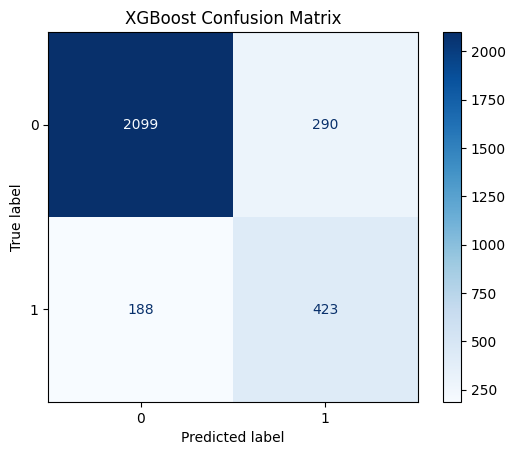

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.gca().grid(False)
plt.title('XGBoost Confusion Matrix')
plt.show()

## 4.6. Choosing Best Model

In [ ]:
models = {
    'Logistic Regression': logistic_pipeline,
    'SVM': svm_pipeline,
    'KNN': knn_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline
}

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.calibration import calibration_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def plot_roc_curve(model, X_test, y_test):
  plt.figure(figsize=(8, 6))
  for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

  plt.plot([0, 1], [0, 1], '--', color='gray')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend(loc='lower right')
  plt.grid(True)
  plt.show()

In [ ]:
def plot_feature_importance_rf(model, features_name, title):
  importances = model.named_steps['rf'].feature_importances_
  idx = np.argsort(importances)[::-1]

  plt.figure(figsize=(10, 6))
  plt.barh(np.array(features_name)[idx], importances[idx])
  plt.title(title)
  plt.gca().grid(False)
  plt.show()

In [ ]:
def plot_feature_importance_xgb(model, features_name, title):
  importances = model.named_steps['xgb'].feature_importances_
  idx = np.argsort(importances)[::-1]

  plt.figure(figsize=(10, 6))
  plt.barh(np.array(features_name)[idx], importances[idx])
  plt.title(title)
  plt.gca().grid(False)
  plt.show()

In [ ]:
def plot_feature_importance_lgb(model, features_name, title):
  importances = model.named_steps['lgb'].feature_importances_
  idx = np.argsort(importances)[::-1]

  plt.figure(figsize=(10, 6))
  plt.barh(np.array(features_name)[idx], importances[idx])
  plt.title(title)
  plt.gca().grid(False)
  plt.show()

In [ ]:
def plot_calibration(models, X_test, y_test):
    plt.figure(figsize=(8,6))

    for name, model in models.items():
        y_prob = model.predict_proba(X_test)[:,1]
        prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label=name)

    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.title("Calibration Curve Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def plot_pr_curve(models, X_test, y_test):
    plt.figure(figsize=(8,6))

    for name, model in models.items():
        y_prob = model.predict_proba(X_test)[:,1]
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        plt.plot(recall, precision, label=name)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

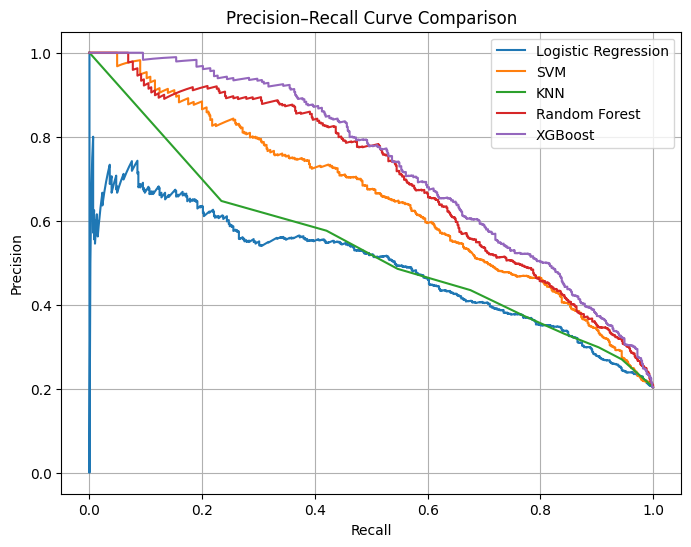

In [ ]:
plot_pr_curve(models, X_test, y_test)

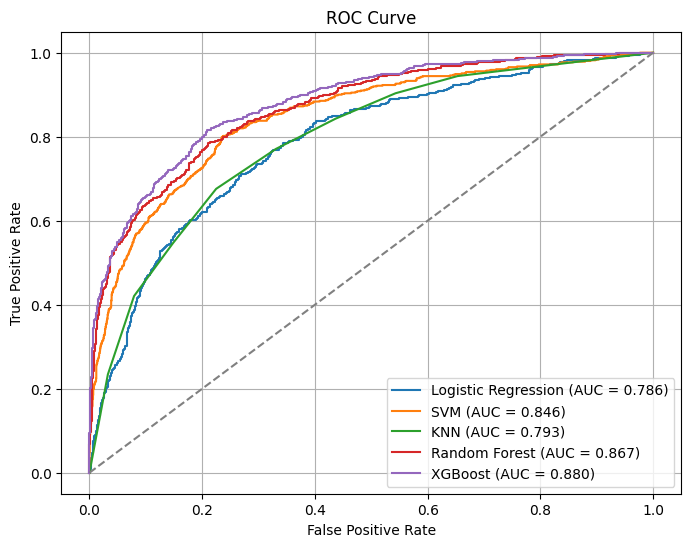

In [ ]:
plot_roc_curve(models, X_test, y_test)

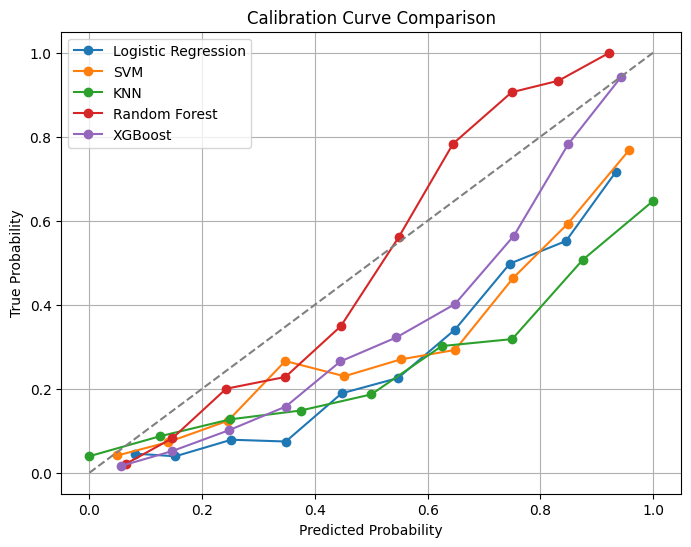

In [ ]:
plot_calibration(models, X_test, y_test)

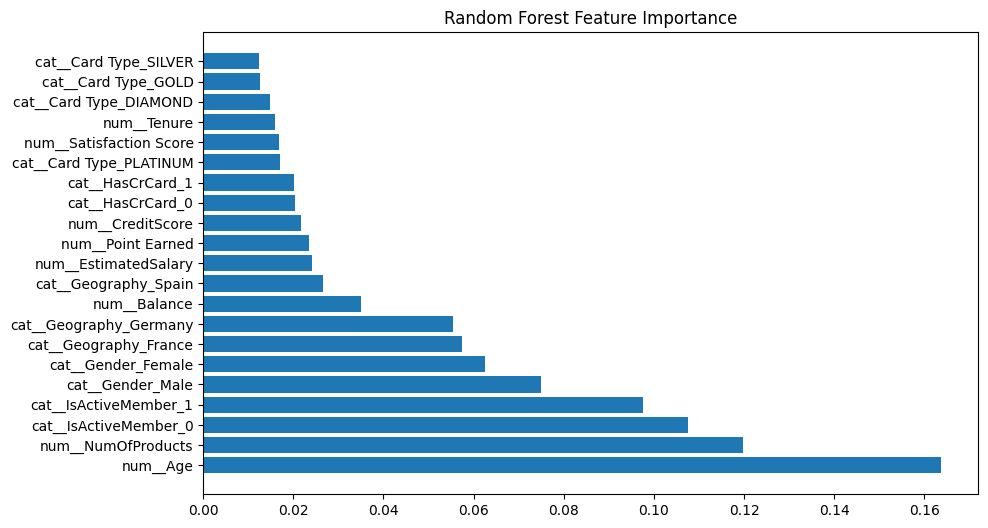

In [ ]:
plot_feature_importance_rf(rf_pipeline, preprocess_tree.get_feature_names_out(), 'Random Forest Feature Importance')

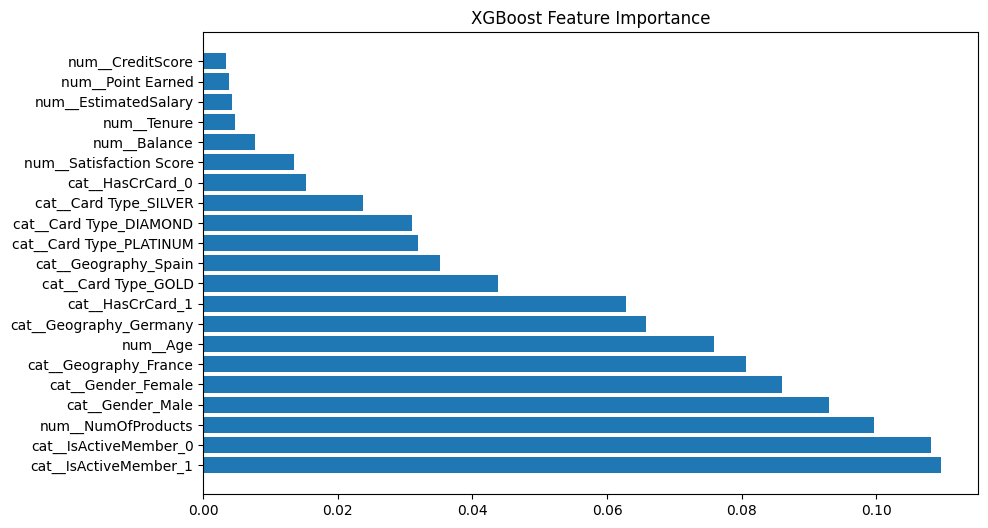

In [ ]:
plot_feature_importance_xgb(xgb_pipeline, preprocess_tree.get_feature_names_out(), 'XGBoost Feature Importance')

We will use XGBoost for better results



Create a save path

In [ ]:
import joblib
import os

model_dir = '/content/drive/MyDrive/models/'

if not os.path.exists(model_dir):
    os.makedirs(model_dir)

joblib.dump(xgb_pipeline, model_dir + 'pipeline_best.pkl')
print(f"XGBoost pipeline saved successfully to {model_dir}")

XGBoost pipeline saved successfully to /content/drive/MyDrive/models/


# 5. Gradio Deploy

In [ ]:
import gradio as gr, joblib, pandas as pd
import numpy as np

try:
  pipe = joblib.load('/content/drive/MyDrive/models/pipeline_best.pkl')
except FileNotFoundError:
  print("Lỗi không tìm thấy file!")

def predict_churn(
    credit_score, geography, geography_other,
    gender, age, tenure, balance, products,
    has_card, active, salary, sat_score,
    card_type, points
):
  # Geography handle
  if geography == "Other":
    geo_value = geography_other.strip()
    if geo_value == "":
      geo_value = "Other"
  else:
      geo_value = geography

  # If not in allowed, then 'Other'
  allowed_geo = ["France", "Germany", "Spain"]
  if geo_value not in allowed_geo:
    geo_value = "Other"

  data = pd.DataFrame([
    {
    'CreditScore': credit_score,
    'Geography': geo_value,
    'Gender': gender,
    'Age': age,
    'Tenure': tenure,
    'Balance': balance,
    'NumOfProducts': products,
    'HasCrCard': has_card,
    'IsActiveMember': active,
    'EstimatedSalary': salary,
    'Satisfaction Score': sat_score,
    'Card Type': card_type,
    'Point Earned': points
  }])

  data['HasCrCard'] = data['HasCrCard'].astype(int)
  data['IsActiveMember'] = data['IsActiveMember'].astype(int)

  prediction = pipe.predict(data)[0]
  prob = pipe.predict_proba(data)[0,1]

  label = 'Rời bỏ' if prob >= 0.5 else 'Giữ lại'

  return f"Khả năng rời bỏ: {prob:.2%} \u2192 {label}"

def show_other_geo(selected):
  return gr.update(visible=(selected == "Other"))

# Gradio interface
with gr.Blocks(title='Customer Churn Prediction') as demo:
    gr.Markdown("# Customer Churn Prediction")
    gr.Markdown("Nhập thông tin khách hàng để dự đoán khả năng rời bỏ.")

    with gr.Row():
        credit_score_input = gr.Number(label='Credit Score')

    with gr.Row():
        geo_dropdown = gr.Dropdown(["France", "Germany", "Spain", "Other"], label="Geography")
        geo_textbox = gr.Textbox(
            label="Enter other country",
            placeholder="Example: Vietnam, Japan, ...",
            visible=False,
            interactive=True
        )

    # On/Off textbox
    geo_dropdown.change(fn=show_other_geo, inputs=geo_dropdown, outputs=geo_textbox)

    with gr.Row():
        gender_input = gr.Radio(['Male','Female'], label='Gender')
        age_input = gr.Slider(18,90,40,label='Age')
        tenure_input = gr.Slider(0,10,5,label='Tenure')

    with gr.Row():
        balance_input = gr.Number(label='Balance')
        products_input = gr.Slider(1,4,1,label='Num of Products')
        has_card_input = gr.Radio([1,0], label='Has Credit Card')

    with gr.Row():
        active_input = gr.Radio([1,0], label='Is Active Member')
        salary_input = gr.Number(label='Estimated Salary')
        sat_score_input = gr.Slider(1,5,3,label='Satisfaction Score')

    with gr.Row():
        card_type_input = gr.Radio(['Diamond','Gold','Silver','Platinum'], label='Card Type')
        points_input = gr.Number(label='Point Earned')

    predict_button = gr.Button("Predict Churn")
    output_text = gr.Textbox(label="Prediction Result")

    predict_button.click(
        fn=predict_churn,
        inputs=[
            credit_score_input, geo_dropdown, geo_textbox,
            gender_input, age_input, tenure_input, balance_input, products_input,
            has_card_input, active_input, salary_input, sat_score_input,
            card_type_input, points_input
        ],
        outputs=output_text
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9c7122d748e3462e8e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
